<a href="https://colab.research.google.com/github/dmitrii-krasnikov/anytask_AESC/blob/main/task_linreg_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [14]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv')
data['plans_university'] = np.where(data['plans_universitypast_failures'] > 0, 1, -1)
data['past_failures'] = data['plans_universitypast_failures'].abs() % 10


data = data.drop(columns=['plans_universitypast_failures'])

data.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0


### Задача 2: пропуски в данных
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [15]:

data = data.fillna(data.mean())
print(f"Осталось пропусков: {data.isnull().sum().sum()}")

Осталось пропусков: 0


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=data.index)

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scores = pd.read_csv('scores.csv', header=None).squeeze()

model = LinearRegression()
cv_scores = cross_val_score(model, data_scaled, scores, cv=4, scoring='neg_mean_squared_error')
initial_mse = -cv_scores.mean()

print(f"MSE = {initial_mse:.4f}")

MSE = 221.7065


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [18]:
file = open('school_support.txt', 'r')
lines = file.readlines()
file.close()

support_indices = []
for line in lines:
    clean_line = line.strip()
    support_indices.append(int(clean_line))

data_scaled['school_support'] = 0
data_scaled.loc[support_indices, 'school_support'] = 1

attendance = pd.read_csv('attendance.csv', sep=';')
data_scaled['attendance_count'] = (attendance == '-').sum(axis=1)

data_scaled[['school_support', 'attendance_count']] = scaler.fit_transform(data_scaled[['school_support', 'attendance_count']])

cv_scores_full = cross_val_score(model, data_scaled, scores, cv=4, scoring='neg_mean_squared_error')
print(f"MSE после добавления = {-cv_scores_full.mean():.4f}")

MSE после добавления = 220.6301


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

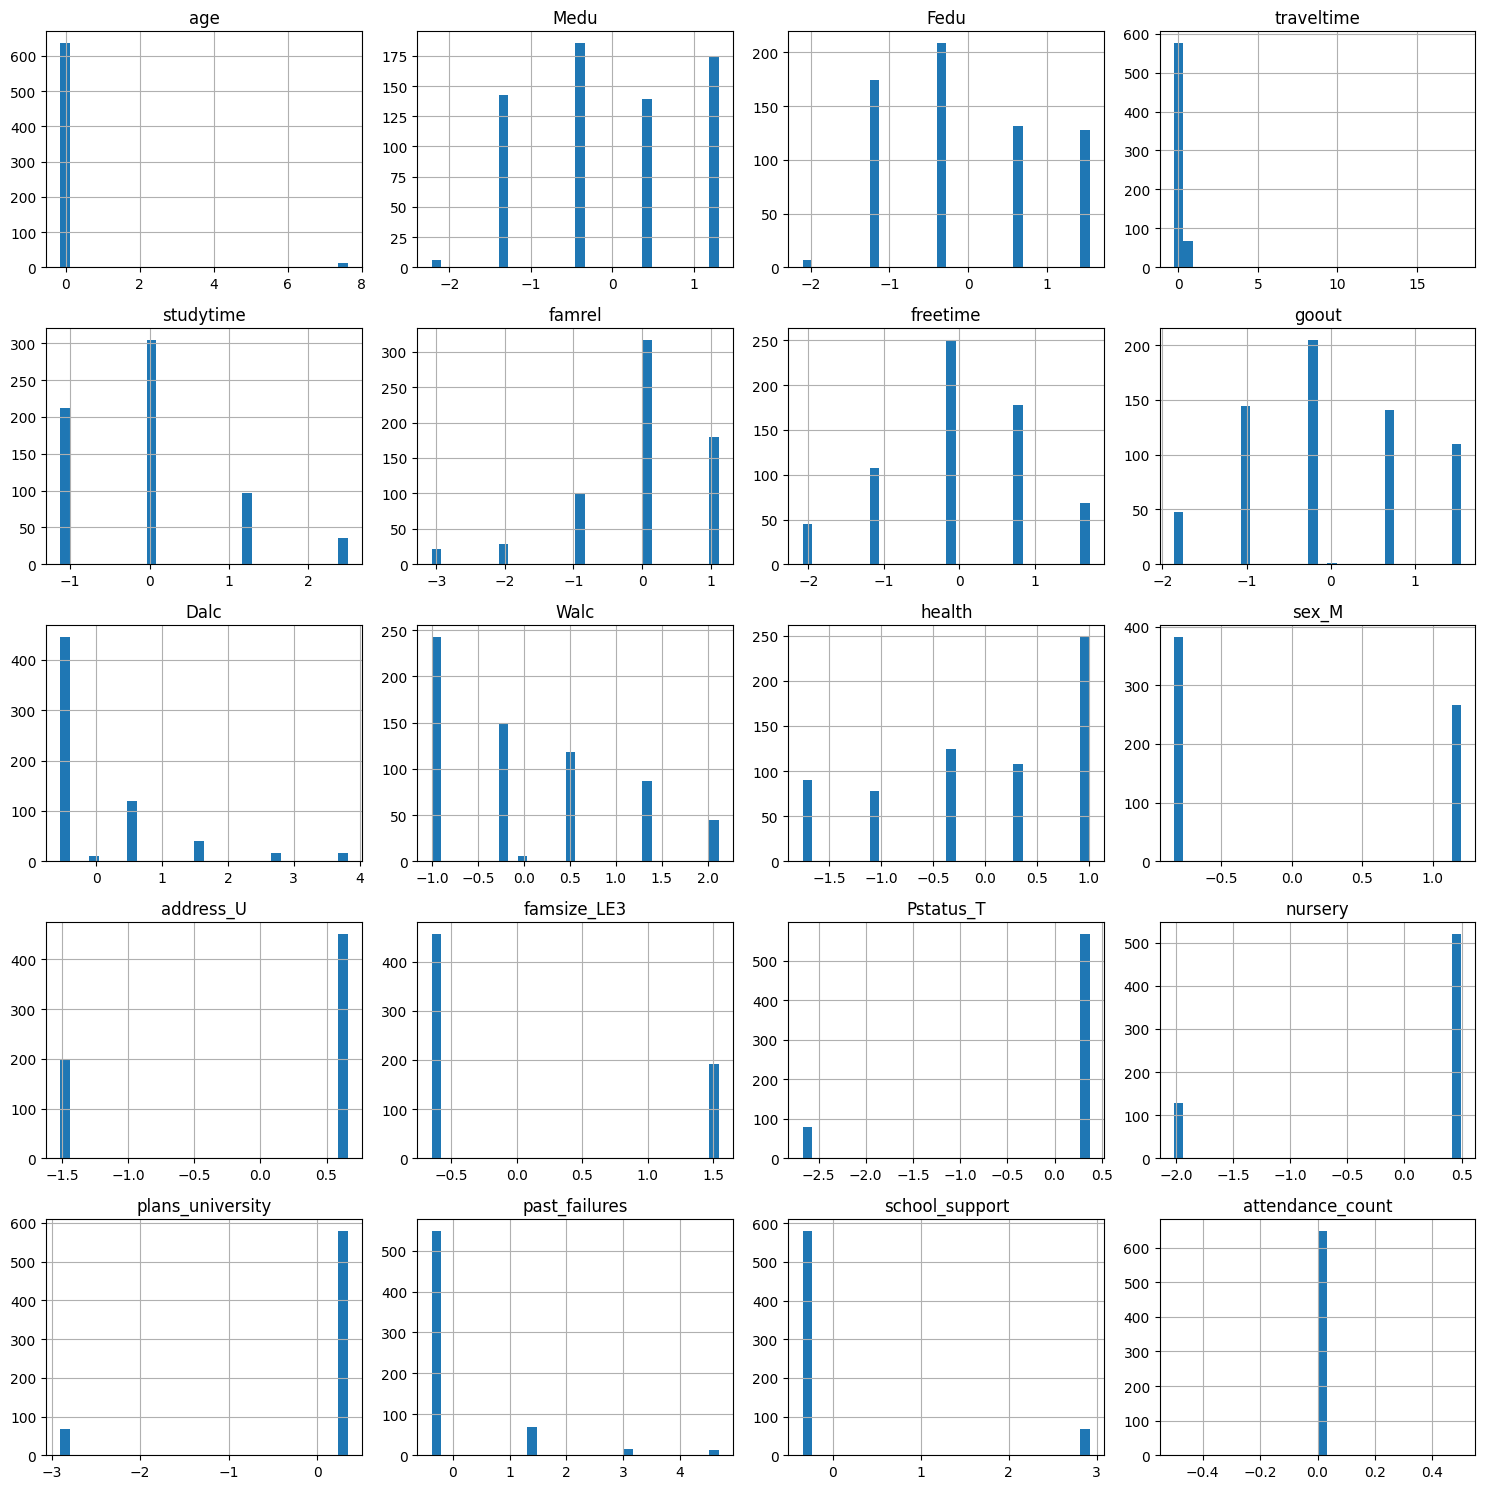

In [19]:
import matplotlib.pyplot as plt


data_scaled.hist(figsize=(15, 15), bins=30)
plt.tight_layout()
plt.show()


if (data['age'] > 100).any():
    data.loc[data['age'] > 100, 'age'] = 2006 - data.loc[data['age'] > 100, 'age']


if (data['traveltime'] > 4).any():
    data.loc[(data['traveltime'] > 4) & (data['traveltime'] < 15), 'traveltime'] = 1
    data.loc[(data['traveltime'] >= 15) & (data['traveltime'] < 30), 'traveltime'] = 2
    data.loc[(data['traveltime'] >= 30) & (data['traveltime'] < 60), 'traveltime'] = 3
    data.loc[(data['traveltime'] >= 60), 'traveltime'] = 4

data_scaled_clean = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

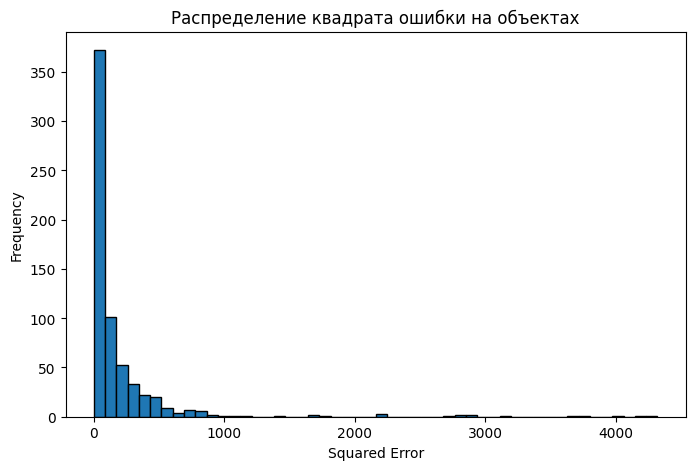

Удалено объектов с аномальной ошибкой: 33


In [33]:
import sklearn
from sklearn import linear_model
regression = LinearRegression().fit(data_scaled_clean, scores)
predictions = regression.predict(data_scaled_clean)
errors = (predictions - scores)**2

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, edgecolor='black')
plt.title('Распределение квадрата ошибки на объектах')
plt.xlabel('Squared Error')
plt.ylabel('Frequency')
plt.show()

error_threshold = np.percentile(errors, 95)
mask_clean = errors < error_threshold

final_data = data_scaled_clean[mask_clean]
final_scores = scores[mask_clean]

print(f"Удалено объектов с аномальной ошибкой: {sum(~mask_clean)}")

In [ ]:
# Your code here
# ...

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных.

In [34]:
final_cv_scores = cross_val_score(model, final_data, final_scores, cv=4, scoring='neg_mean_squared_error')
final_mse = -final_cv_scores.mean()

print(f"Исходная MSE: {initial_mse:.4f}")
print(f"MSE после добавления признаков и очистки от выбросов: {final_mse:.4f}")


report = """
Наблюдения:
1. Заполнение пропусков и исправление типа данных позволило обучить базовую модель
2. Добавление данных других файлов повысило предсказательную способность, так как посещаемость напрямую коррелирует с итоговой оценкой
3. Очистка от выбросов существенно снизила итоговую оценку
"""
print(report)

Исходная MSE: 221.7065
MSE после добавления признаков и очистки от выбросов: 118.9410

Наблюдения:
1. Заполнение пропусков и исправление типа данных позволило обучить базовую модель
2. Добавление данных других файлов повысило предсказательную способность, так как посещаемость напрямую коррелирует с итоговой оценкой
3. Очистка от выбросов (например, исправление года рождения на возраст и фильтрация экстремальных ошибок предсказания) существенно снизила итоговую оценку

